In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Simulated Solar Power Profile')

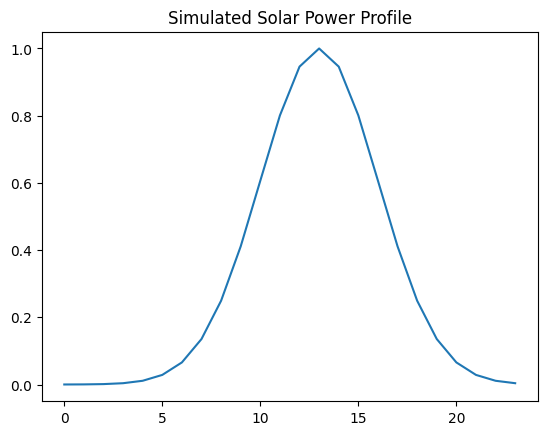

In [4]:
hours = np.arange(24)
center = 13.0     # solar noon
sigma = 3.0       # width of daylight
profile = np.exp(-0.5 * ((hours - center) / sigma) ** 2)

plt.plot(hours, profile)
plt.title("Simulated Solar Power Profile")

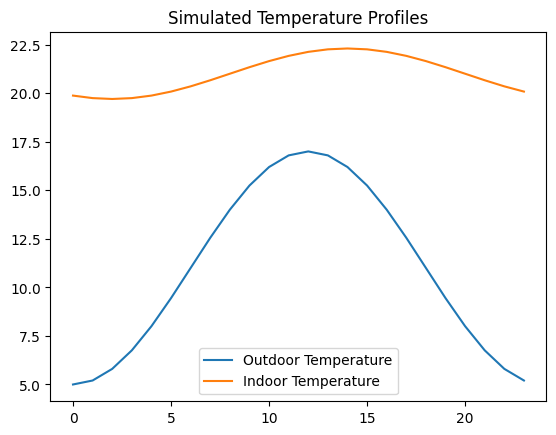

In [5]:
tout = 11.0 + 6.0 * np.sin((hours - 6) * np.pi / 12.0) # Outdoor temperature profile with a peak in the afternoon
tin = 21.0 + 1.3 * np.sin((hours - 8) * np.pi / 12.0) # Indoor temperature profile with a smaller amplitude and a slight delay
plt.figure()
plt.plot(hours, tout, label="Outdoor Temperature")
plt.plot(hours, tin, label="Indoor Temperature")
plt.title("Simulated Temperature Profiles")
plt.legend()
plt.show()

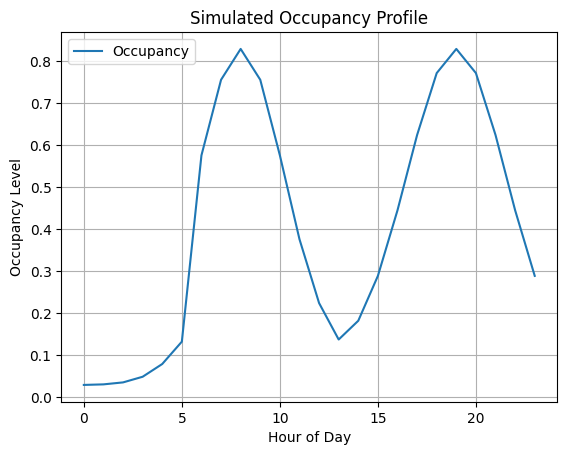

In [7]:
morning = np.exp(-0.5 * ((hours - 8) / 2.2) ** 2)
evening = np.exp(-0.5 * ((hours - 19) / 2.5) ** 2)
occupancy = 0.08 + 0.75 * np.maximum(morning, evening)
occupancy[(hours >= 0) & (hours <= 5)] *= 0.35

plt.figure()
plt.plot(hours, occupancy, label="Occupancy")
plt.title("Simulated Occupancy Profile")
plt.xlabel("Hour of Day")
plt.ylabel("Occupancy Level")
plt.grid()
plt.legend()
plt.show()

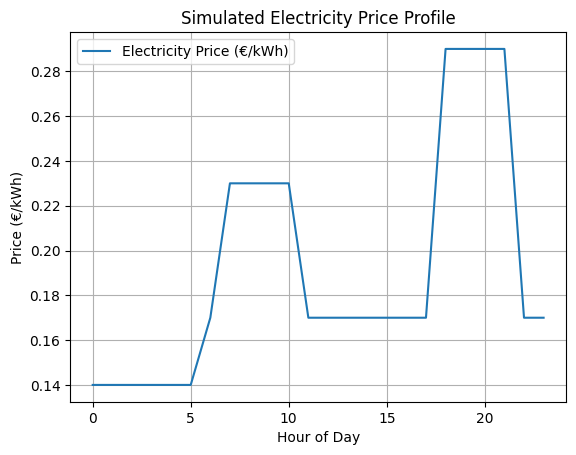

In [8]:
cbuy = np.full(24, 0.17)
cbuy[(hours >= 7) & (hours < 11)] = 0.23
cbuy[(hours >= 18) & (hours < 22)] = 0.29
cbuy[(hours >= 0) & (hours < 6)] = 0.14

plt.figure()
plt.plot(hours, cbuy, label="Electricity Price (€/kWh)")
plt.title("Simulated Electricity Price Profile")
plt.xlabel("Hour of Day")
plt.ylabel("Price (€/kWh)")
plt.grid()
plt.legend()
plt.show()

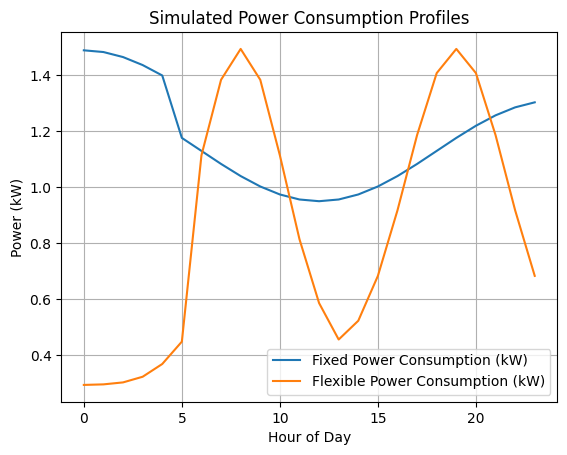

In [10]:
tmin_c = 20.0
pfixe = 0.8 + 0.03 * np.maximum(0.0, 22.0 - tout) + 0.18 * (tin < tmin_c)
pflex = 0.25 + 1.5 * occupancy

plt.figure()
plt.plot(hours, pfixe, label="Fixed Power Consumption (kW)")
plt.plot(hours, pflex, label="Flexible Power Consumption (kW)")
plt.title("Simulated Power Consumption Profiles")
plt.xlabel("Hour of Day")
plt.ylabel("Power (kW)")
plt.grid()
plt.legend()
plt.show()

In [19]:
dataset = pd.read_csv("processed/donnees_reelles_clean_2026-02-08.csv")
dataset.head()

,heure,jour,mois,annee,tfrigo,Tmin,Tmax,Tout_reel,Tin_reel,G,alpha_presence_reel,PV_reel,Pfixe,Pflex_reel,Pin,Pgo,Ebat,S,Cbuy_reel,Csell_reel
0,0,8,2,2026,4.0,20.0,25.0,5.323,19.040,38.877,0.0616,0.238,1.478,0.636,0.000,0.0,4.024,0,0.1378,0.0854
1,1,8,2,2026,4.0,20.0,25.0,5.159,19.749,0.000,0.0515,0.000,1.315,0.107,0.000,0.0,2.527,0,0.1162,0.0683
2,2,8,2,2026,4.0,20.0,25.0,5.769,20.177,0.000,0.1534,0.000,1.310,0.501,0.000,0.0,0.620,0,0.1305,0.0824
3,3,8,2,2026,4.0,20.0,25.0,6.592,19.861,38.202,0.0419,0.308,1.318,0.006,0.427,0.0,0.000,0,0.1460,0.0910
4,4,8,2,2026,4.0,20.0,25.0,5.630,19.980,0.000,0.0000,0.000,1.418,0.088,1.506,0.0,0.000,0,0.1205,0.0646


In [20]:
dataset.columns[4]

'tfrigo'

tfrigo: float64


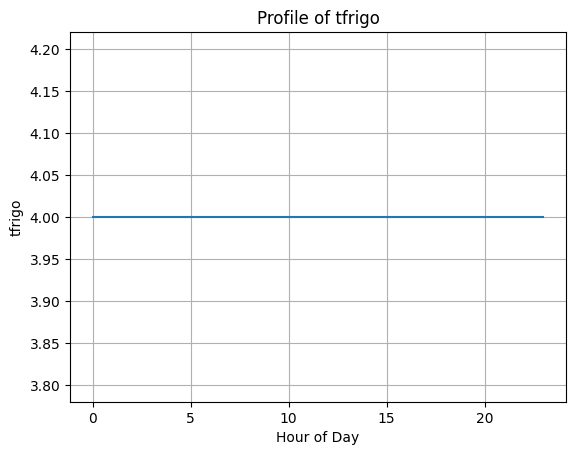

Tmin: float64


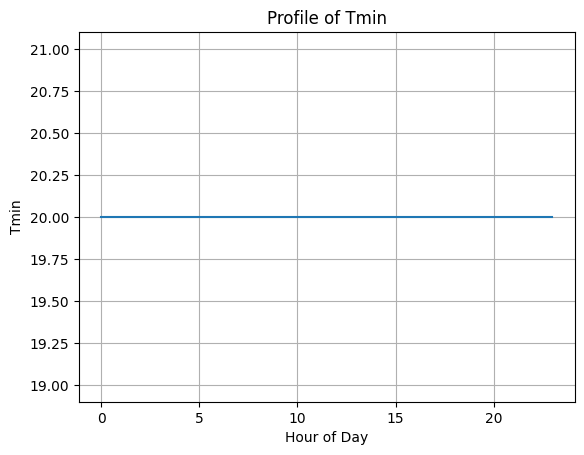

Tmax: float64


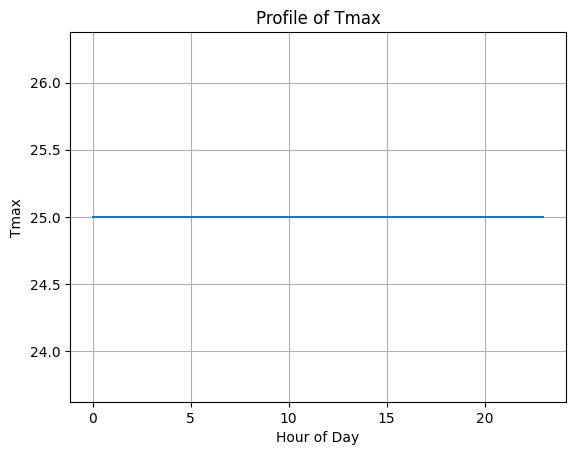

Tout_reel: float64


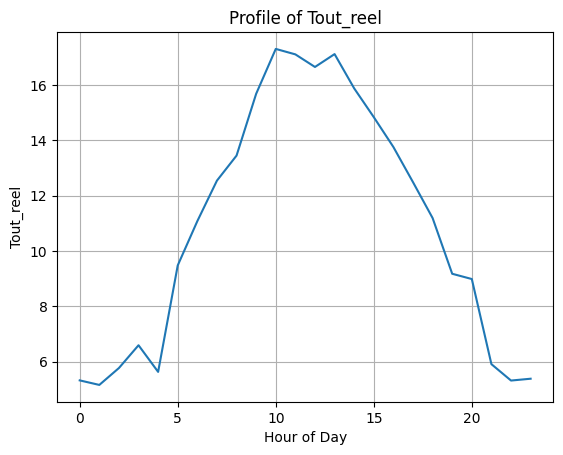

Tin_reel: float64


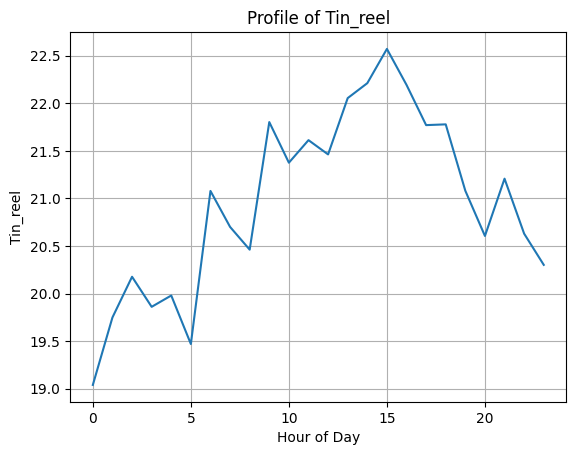

G: float64


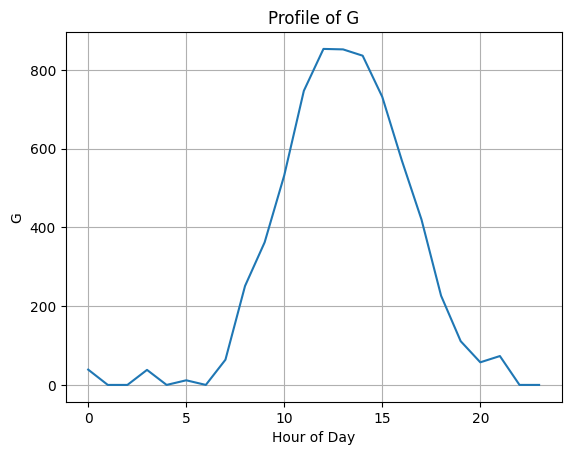

alpha_presence_reel: float64


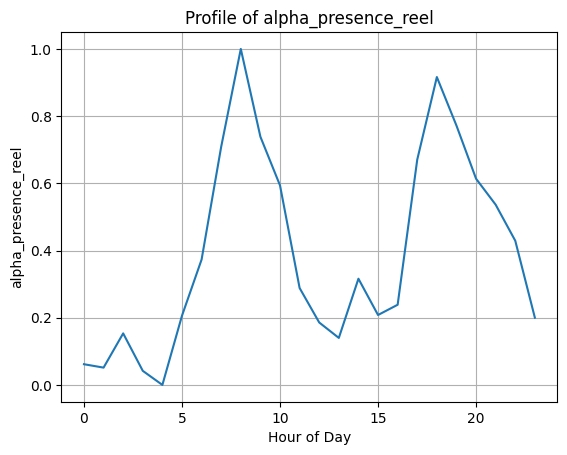

PV_reel: float64


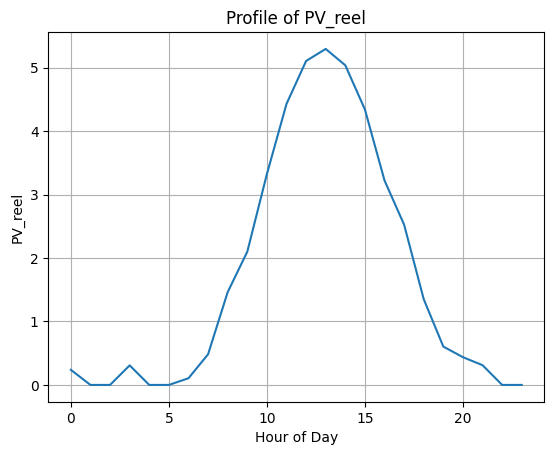

Pfixe: float64


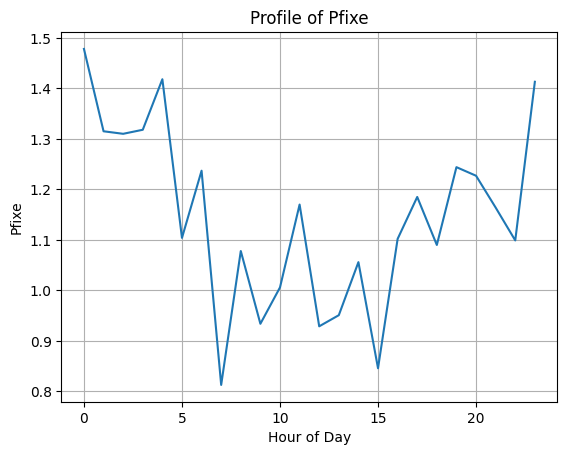

Pflex_reel: float64


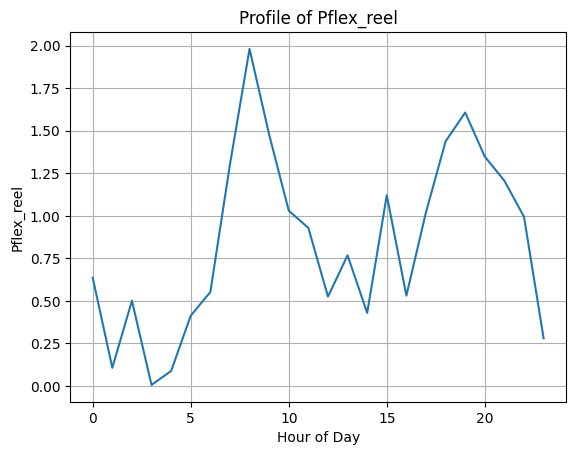

Pin: float64


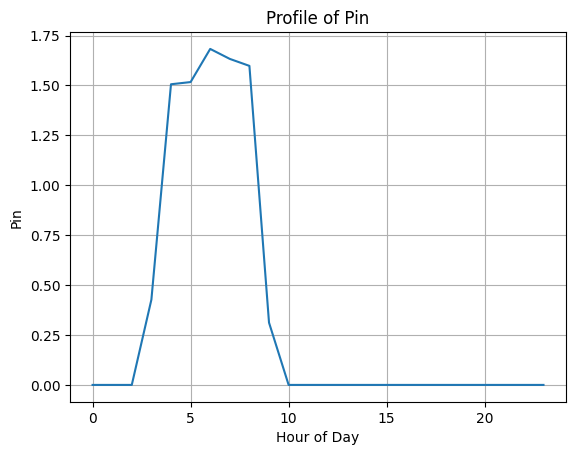

Pgo: float64


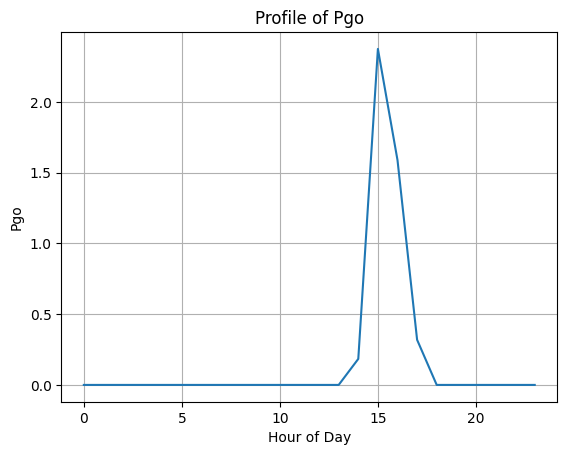

Ebat: float64


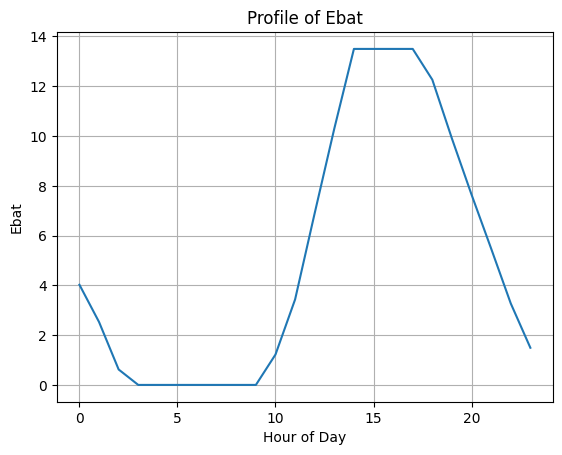

S: int64


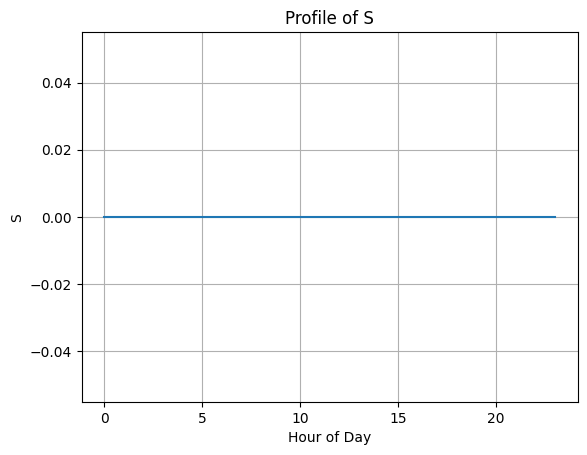

Cbuy_reel: float64


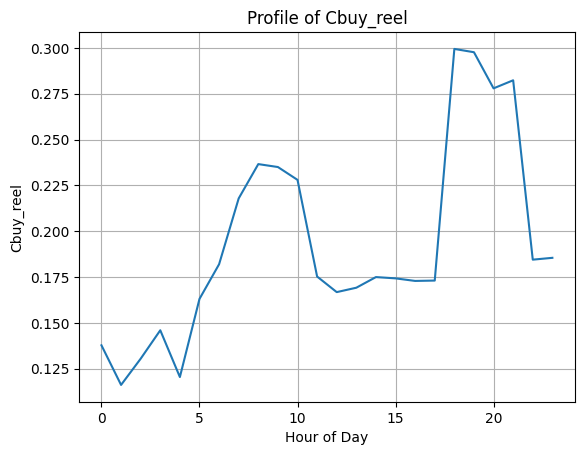

Csell_reel: float64


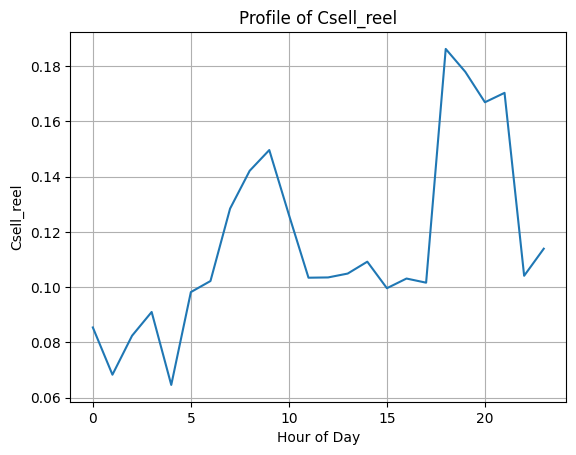

In [21]:
for col in dataset.columns[4:]:
    print(f"{col}: {dataset[col].dtype}")
    plt.figure()
    plt.plot(dataset["heure"], dataset[col])
    plt.title(f"Profile of {col}")
    plt.xlabel("Hour of Day")
    plt.ylabel(col)
    plt.grid()
    plt.show()